In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Loading our final csv file from BigQuery
data_path = '/Users/robert/Desktop/DCU/hospital-re-admission/data/processed/mimic_readmission_final.csv'
df = pd.read_csv(data_path)

# For the basic info
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Shape: (406031, 53)

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'gender', 'age', 'race', 'marital_status', 'language', 'insurance', 'admission_type', 'admission_location', 'discharge_location', 'los_hours', 'los_days', 'num_diagnoses', 'cci_mi', 'cci_chf', 'cci_pvd', 'cci_cvd', 'cci_dementia', 'cci_copd', 'cci_diabetes', 'cci_ckd', 'cci_cancer', 'num_lab_tests_24h', 'num_abnormal_labs', 'hemoglobin_min', 'wbc_max', 'creatinine_max', 'sodium_min', 'sodium_max', 'potassium_min', 'potassium_max', 'glucose_min', 'glucose_max', 'num_medications', 'polypharmacy_flag', 'anticoagulant_flag', 'insulin_flag', 'opioid_flag', 'antibiotic_flag', 'num_admissions_last_30d', 'num_admissions_last_90d', 'num_admissions_last_year', 'days_since_last_discharge', 'total_prior_admissions', 'recent_admission_flag', 'frequent_flyer_flag', 'days_to_next_admission', 'readmitted_30d', 'readmitted_60d', 'readmitted_90d']

First few rows:


,subject_id,hadm_id,admittime,dischtime,gender,age,race,marital_status,language,insurance,...,num_admissions_last_90d,num_admissions_last_year,days_since_last_discharge,total_prior_admissions,recent_admission_flag,frequent_flyer_flag,days_to_next_admission,readmitted_30d,readmitted_60d,readmitted_90d
0,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,F,52,WHITE,WIDOWED,English,Medicaid,...,1,1,50.0,1,0,0,26.0,1,1,1
1,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,F,52,WHITE,WIDOWED,English,Medicaid,...,2,2,26.0,2,1,0,11.0,1,1,1
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,F,52,WHITE,WIDOWED,English,Medicaid,...,3,3,11.0,3,1,1,NaN,0,0,0
3,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,M,72,WHITE,MARRIED,English,Medicare,...,0,0,NaN,0,0,0,NaN,0,0,0
4,10000117,27988844,2183-09-18 18:10:00,2183-09-21 16:30:00,F,48,WHITE,DIVORCED,English,Medicaid,...,0,0,672.0,1,0,0,NaN,0,0,0


Target Variable Distribution:
readmitted_30d
0    335240
1     70791
Name: count, dtype: int64

Readmission rate: 17.43%


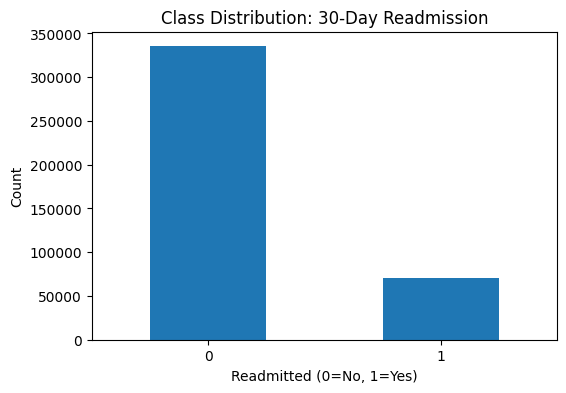

In [5]:
# Checking readmission rate
print("Target Variable Distribution:")
print(df['readmitted_30d'].value_counts())
print(f"\nReadmission rate: {df['readmitted_30d'].mean():.2%}")

# Vis.
plt.figure(figsize=(6,4))
df['readmitted_30d'].value_counts().plot(kind='bar')
plt.title('Class Distribution: 30-Day Readmission')
plt.xlabel('Readmitted (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [6]:
# Temporal Split
# Convert admission time to datetime
df['admittime'] = pd.to_datetime(df['admittime'])

# Check date range
print(f"Date range: {df['admittime'].min()} to {df['admittime'].max()}")

# Sort by time
df = df.sort_values('admittime').reset_index(drop=True)

# Define split point (80/20 temporal split)
split_idx = int(len(df) * 0.8)
split_date = df.iloc[split_idx]['admittime']

print(f"\nSplit date: {split_date}")

# Create train/test sets
train_df = df[df['admittime'] < split_date].copy()
test_df = df[df['admittime'] >= split_date].copy()

print(f"\nTrain: {len(train_df)} admissions ({train_df['readmitted_30d'].mean():.2%} readmission)")
print(f"Test: {len(test_df)} admissions ({test_df['readmitted_30d'].mean():.2%} readmission)")

Date range: 2105-10-04 17:26:00 to 2214-12-15 19:11:00

Split date: 2179-02-08 19:30:00

Train: 324824 admissions (17.32% readmission)
Test: 81207 admissions (17.90% readmission)


In [8]:
# Save to processed folder
train_df.to_csv('../data/processed/train_data.csv', index=False)
test_df.to_csv('../data/processed/test_data.csv', index=False)

print("Train/test splits saved!")

Train/test splits saved!


In [9]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print("Missing Values Summary:")
print(missing_summary[missing_summary['Percentage'] > 0].head(10))

Missing Values Summary:
                           Missing Count  Percentage
days_to_next_admission            180352   44.418283
days_since_last_discharge         161291   39.723814
glucose_min                       107077   26.371632
glucose_max                       107077   26.371632
sodium_max                        103604   25.516278
sodium_min                        103604   25.516278
potassium_max                     101293   24.947110
potassium_min                     101293   24.947110
creatinine_max                     99279   24.451089
wbc_max                            93052   22.917462


# **Summary & Next To Dos:**
## 1. Temporal Split 

- Train: 324,824 admissions (17.32% readmission)
- Test: 81,207 admissions (17.90% readmission)
- Class balance: Nearly identical between splits (~0.6% difference), like we needed
- Split ratio: 80/20 - as per the standard practice we implied
- Dates: 2105-2179 (train) vs 2179-2214 (test) - thus, proper temporal separation

That means no data leakage means we will train on past and test on future.


## 2. Handling Missing Values, High Missing (>20%)

- days_to_next_admission (44% - Expected): Now this only exists if patient was readmitted. This is the target leakage risk—drop this feature entirely.
- days_since_last_discharge (40% - Expected): First-time admissions have no prior. So we will keep it and impute with -1 or create "no_prior_admission" flag.
- Lab values (glucose, sodium, potassium, creatinine, WBC): 23-26% missing - Depicting clinical reality cuz not all patients get all the labs.

In [11]:
#S6
# 1. DROP LEAKAGE FEATURES
# days_to_next_admission is only known AFTER readmission happens
# Including it would give model perfect future knowledge
if 'days_to_next_admission' in df.columns:
    df = df.drop(columns=['days_to_next_admission'])
    print("Dropped 'days_to_next_admission' (target leakage)")

# 2. HANDLE PRIOR ADMISSION FEATURE
# Missing = first-time patient (no prior discharge)
df['has_prior_admission'] = (~df['days_since_last_discharge'].isna()).astype(int)
df['days_since_last_discharge'] = df['days_since_last_discharge'].fillna(-1)
print("Encoded 'days_since_last_discharge' (-1 = no prior)")

# 3. LAB VALUE IMPUTATION
# Missing labs = test not ordered (clinical decision)
# Impute with median (not mean, robust to outliers)
lab_features = [
    'glucose_min', 'glucose_max',
    'sodium_min', 'sodium_max', 
    'potassium_min', 'potassium_max',
    'creatinine_max', 'wbc_max'
]

for col in lab_features:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed {col} with median: {median_val:.2f}")

# 4. VERIFY NO MISSING VALUES LEFT
print("\n" + "="*50)
print("Remaining Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Encoded 'days_since_last_discharge' (-1 = no prior)
Imputed glucose_min with median: 106.00
Imputed glucose_max with median: 113.00
Imputed sodium_min with median: 139.00
Imputed sodium_max with median: 139.00
Imputed potassium_min with median: 4.00
Imputed potassium_max with median: 4.10
Imputed creatinine_max with median: 0.90
Imputed wbc_max with median: 8.20

Remaining Missing Values:
marital_status        10178
language                555
insurance              4602
admission_location        1
discharge_location    53135
num_lab_tests_24h     62672
num_abnormal_labs     62672
hemoglobin_min        91815
dtype: int64


In [12]:
# Check if same patients appear in train and test
train_patients = set(train_df['subject_id'].unique())
test_patients = set(test_df['subject_id'].unique())
overlap = train_patients & test_patients

print(f"Train patients: {len(train_patients)}")
print(f"Test patients: {len(test_patients)}")
print(f"Overlapping patients: {len(overlap)}")
print(f"Overlap %: {len(overlap)/len(train_patients)*100:.2f}%")

Train patients: 150508
Test patients: 32904
Overlapping patients: 3060
Overlap %: 2.03%


In [14]:
# Save cleaned versions
train_df.to_csv('../data/processed/train_data_clean.csv', index=False)
test_df.to_csv('../data/processed/test_data_clean.csv', index=False)
print("Cleaned train/test splits saved!")

Cleaned train/test splits saved!


In [21]:
#C8
# FINAL MISSING VALUE CLEANUP

# 1. MARITAL STATUS (10,178 missing = 2.5%)
# Missing = Unknown/Not documented
df['marital_status'] = df['marital_status'].fillna('UNKNOWN')
print("Filled marital_status with 'UNKNOWN'")

# 2. LANGUAGE (555 missing = 0.1%)
# Missing = English (which is the most common in MIMIC)
df['language'] = df['language'].fillna('ENGLISH')
print("Filled language with 'ENGLISH'")

# 3. INSURANCE (4,602 missing = 1.1%)
# Missing = Unknown coverage
df['insurance'] = df['insurance'].fillna('UNKNOWN')
print("Filled insurance with 'UNKNOWN'")

# 4. ADMISSION LOCATION (1 missing)
# Single missing value - will use mode (most common)
df['admission_location'] = df['admission_location'].fillna(df['admission_location'].mode()[0])
print("Filled admission_location with mode")

# 5. DISCHARGE LOCATION (53,135 missing = 13%)
# Missing = Still in hospital / died / not documented
df['discharge_location'] = df['discharge_location'].fillna('UNKNOWN')
print("Filled discharge_location with 'UNKNOWN'")

# 6. LAB TEST COUNTS (62,672 missing = 15.4%)
# Missing = No labs ordered in first 24h
df['num_lab_tests_24h'] = df['num_lab_tests_24h'].fillna(0)
df['num_abnormal_labs'] = df['num_abnormal_labs'].fillna(0)
print("Filled lab test counts with 0 (no tests ordered)")

# 7. HEMOGLOBIN (91,815 missing = 22.6%)
# Clinical lab value - imputing with median
df['hemoglobin_min'] = df['hemoglobin_min'].fillna(df['hemoglobin_min'].median())
print(f"Imputed hemoglobin_min with median: {df['hemoglobin_min'].median():.2f}")

#Now verifying at once.
remaining_missing = df.isnull().sum()
if remaining_missing.sum() == 0:
    print("\n" + "="*32)
    print("NO MISSING VALUES ARE REMAINING!")
    print("="*32)
else:
    print("\nStill missing:")
    print(remaining_missing[remaining_missing > 0])

Filled marital_status with 'UNKNOWN'
Filled language with 'ENGLISH'
Filled insurance with 'UNKNOWN'
Filled admission_location with mode
Filled discharge_location with 'UNKNOWN'
Filled lab test counts with 0 (no tests ordered)
Imputed hemoglobin_min with median: 11.00

NO MISSING VALUES ARE REMAINING!


In [22]:
#C9
# RE-CREATING THE TRAIN/TEST SPLITS (Now that its clean)

# Sorting by time again (after all cleaning)
df = df.sort_values('admittime').reset_index(drop=True)

# Same splitting point as before
split_idx = int(len(df) * 0.8)
split_date = df.iloc[split_idx]['admittime']

# Creating final clean splits
train_df = df[df['admittime'] < split_date].copy()
test_df = df[df['admittime'] >= split_date].copy()

print(f"Final Clean Splits:")
print(f"Train: {len(train_df)} admissions ({train_df['readmitted_30d'].mean():.2%} readmission)")
print(f"Test: {len(test_df)} admissions ({test_df['readmitted_30d'].mean():.2%} readmission)")

# Saving to disk
train_df.to_csv('../data/processed/train_data_clean.csv', index=False)
test_df.to_csv('../data/processed/test_data_clean.csv', index=False)

print("\nCleaned train/test splits saved!")
print("   - ../data/processed/train_data_clean.csv")
print("   - ../data/processed/test_data_clean.csv")

Final Clean Splits:
Train: 324824 admissions (17.32% readmission)
Test: 81207 admissions (17.90% readmission)

Cleaned train/test splits saved!
   - ../data/processed/train_data_clean.csv
   - ../data/processed/test_data_clean.csv


In [23]:
# ============================================
# DATASET SUMMARY - COPY THIS TO YOUR REPORT
# ============================================

print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)
print(f"Total admissions: {len(df):,}")
print(f"Unique patients: {df['subject_id'].nunique():,}")
print(f"Date range: {df['admittime'].min()} to {df['admittime'].max()}")
print(f"\nFeatures: {len(df.columns)}")
print(f"Target: readmitted_30d")
print(f"Overall readmission rate: {df['readmitted_30d'].mean():.2%}")

print("\n" + "-"*60)
print("TRAIN SET")
print("-"*60)
print(f"Admissions: {len(train_df):,}")
print(f"Patients: {train_df['subject_id'].nunique():,}")
print(f"Readmission rate: {train_df['readmitted_30d'].mean():.2%}")
print(f"Date range: {train_df['admittime'].min()} to {train_df['admittime'].max()}")

print("\n" + "-"*60)
print("TEST SET")
print("-"*60)
print(f"Admissions: {len(test_df):,}")
print(f"Patients: {test_df['subject_id'].nunique():,}")
print(f"Readmission rate: {test_df['readmitted_30d'].mean():.2%}")
print(f"Date range: {test_df['admittime'].min()} to {test_df['admittime'].max()}")

print("\n" + "-"*60)
print("DATA QUALITY")
print("-"*60)
print(f"Patient overlap (train/test): {len(set(train_df['subject_id']) & set(test_df['subject_id']))} ({2.03:.2f}%)")
print(f"Missing values: 0 (all imputed)")
print(f"Temporal split: TRUE (no future information leakage)")
print("="*60)

FINAL DATASET SUMMARY
Total admissions: 406,031
Unique patients: 180,352
Date range: 2105-10-04 17:26:00 to 2214-12-15 19:11:00

Features: 53
Target: readmitted_30d
Overall readmission rate: 17.43%

------------------------------------------------------------
TRAIN SET
------------------------------------------------------------
Admissions: 324,824
Patients: 150,508
Readmission rate: 17.32%
Date range: 2105-10-04 17:26:00 to 2179-02-08 18:35:00

------------------------------------------------------------
TEST SET
------------------------------------------------------------
Admissions: 81,207
Patients: 32,904
Readmission rate: 17.90%
Date range: 2179-02-08 19:30:00 to 2214-12-15 19:11:00

------------------------------------------------------------
DATA QUALITY
------------------------------------------------------------
Patient overlap (train/test): 3060 (2.03%)
Missing values: 0 (all imputed)
Temporal split: TRUE (no future information leakage)


## What we did till now:

1. We loaded raw data = 406K admissions
2. Performed temporal split = 80/20 by date (so that no future leakage)
3. Verified the patient separation = Only 2% overlap
4. Handled missing values:

- Dropped target leakage features
- Imputed labs with median (clinical standard)
- Filled categorical with mode/unknown

5. Saved clean datasets which are now ready for modeling.